# Análise do MIRI.SA (Figuras 3 a 9 e Tabelas)

Este notebook contém as rotinas para gerar as figuras e tabelas do Artigo 1 a partir da série climatológica (1991–2020) e projetada (2018–2025) do índice MIRI.SA, além das comparações com o índice RMM (BoM).

In [12]:
# ===========================
# Setup inicial
# ===========================
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

import datetime
import time as time
import os.path
import pandas as pd
from datetime import date
import matplotlib.patches as mpatches


file_clim = "../../AA03-RData_TxT/MIRISA_CLIM_19910301_20200228_CREATE_20230225.txt"
file_proj = "../../AA03-RData_TxT/MIRISA_REALT_20200301_20250907_CREATE_20250922.txt"

# Ler arquivos (ajuste do separador se necessário)
clim = pd.read_csv(file_clim, sep=";") #, parse_dates={"date": ["Year", "Month", "Day"]})
proj = pd.read_csv(file_proj, sep=";") #, parse_dates={"date": ["Year", "Month", "Day"]})

# Exemplo: placeholders das séries (substitua pelos seus dados)
miri_climA = clim["Amplitude"]
miri_climF = clim["Phase"]
miri_projA = proj["Amplitude"]
miri_projF = proj["Phase"]



# rmm_amp = pd.Series(...)
# precip = xr.DataArray(...)
# olr = xr.DataArray(...)


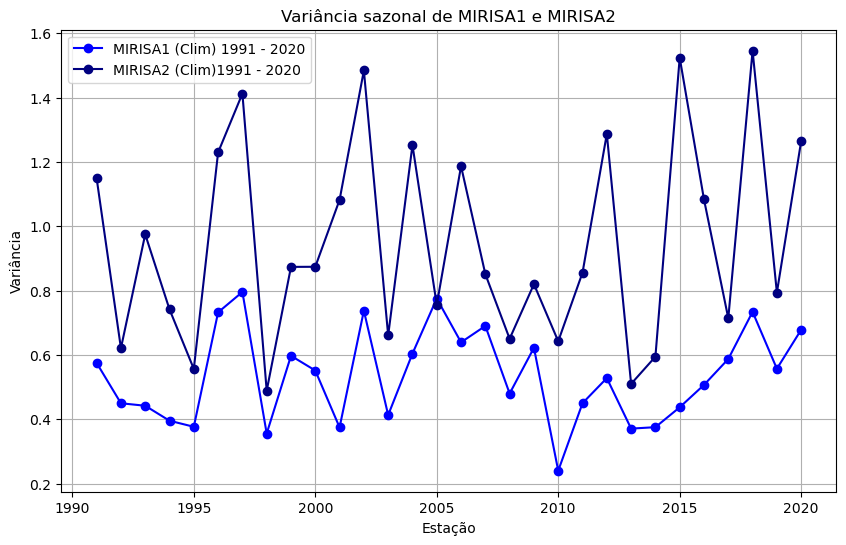

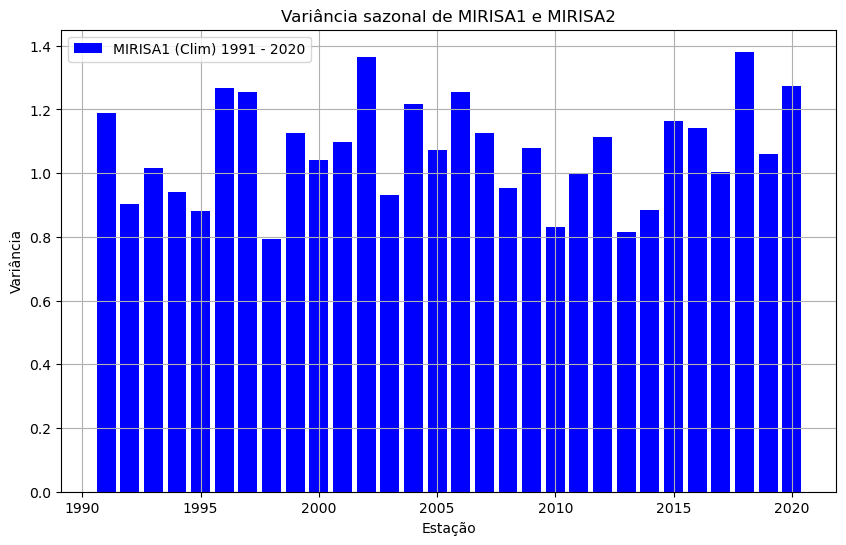

In [43]:
# ============================
# 2. Criar colunas auxiliares
# ============================
def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

for df in [clim, proj]:
#    df["Month"] = df["date"]
    df["Season"] = df["Month"].apply(month_to_season)

# ============================
# 3. Variância sazonal MIRISA1 e MIRISA2
# ============================
var_clim = clim.groupby("Year")[["MIRISA1c1","MIRISA1c2"]].var()
var_proj = proj.groupby("Year")[["MIRISA1c1","MIRISA1c2"]].var()
amp_clim = clim.groupby("Year")[["Amplitude"]].mean()

plt.figure(figsize=(10,6))
plt.plot(var_clim.index, var_clim["MIRISA1c1"],color="blue", marker="o", label="MIRISA1 (Clim) 1991 - 2020")
plt.plot(var_clim.index, var_clim["MIRISA1c2"],color="navy", marker="o", label="MIRISA2 (Clim)1991 - 2020")
plt.title("Variância sazonal de MIRISA1 e MIRISA2")
plt.ylabel("Variância")
plt.xlabel("Estação")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,6))
plt.bar(amp_clim.index,amp_clim["Amplitude"],color="blue", label="MIRISA1 (Clim) 1991 - 2020")
plt.title("Variância sazonal de MIRISA1 e MIRISA2")
plt.ylabel("Variância")
plt.xlabel("Estação")
plt.legend()
plt.grid(True)
plt.show()


0       1.354
1       1.288
2       1.185
3       1.061
4       0.936
        ...  
1913    1.534
1914    1.357
1915    1.180
1916    1.059
1917    1.053
Name: Amplitude, Length: 552, dtype: float64


(array([0.10171781, 0.07628836, 0.12714726, 0.33058288, 0.35601234,
        0.38144179, 0.43230069, 0.78831303, 0.89003084, 1.0171781 ,
        0.55944796, 0.35601234, 0.45773015, 0.4831596 , 0.5340185 ,
        0.4831596 , 0.63573631, 0.66116577, 0.58487741, 0.4831596 ,
        0.58487741, 0.4831596 , 0.45773015, 0.33058288, 0.4831596 ,
        0.30515343, 0.10171781, 0.20343562, 0.20343562, 0.25429453,
        0.10171781, 0.10171781, 0.02542945, 0.05085891, 0.07628836,
        0.02542945, 0.07628836, 0.07628836, 0.05085891, 0.02542945,
        0.05085891, 0.05085891, 0.02542945, 0.        , 0.        ,
        0.02542945, 0.        , 0.02542945, 0.02542945, 0.07628836]),
 array([0.104  , 0.17524, 0.24648, 0.31772, 0.38896, 0.4602 , 0.53144,
        0.60268, 0.67392, 0.74516, 0.8164 , 0.88764, 0.95888, 1.03012,
        1.10136, 1.1726 , 1.24384, 1.31508, 1.38632, 1.45756, 1.5288 ,
        1.60004, 1.67128, 1.74252, 1.81376, 1.885  , 1.95624, 2.02748,
        2.09872, 2.16996, 2.2412 ,

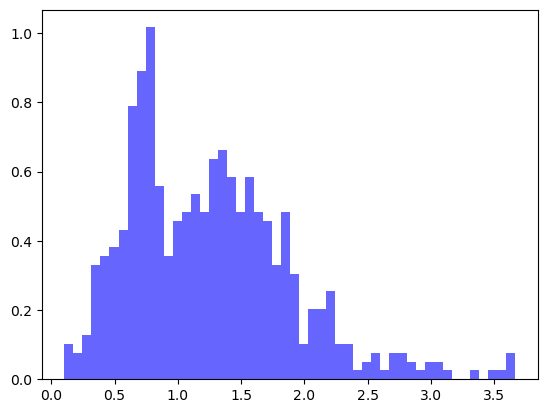

In [34]:

# ============================
# 4. Boxplot sazonal da Amplitude
# ============================
# amp_clim = clim.groupby("Season")["Amplitude"].apply(list)
# amp_proj = proj.groupby("Season")["Amplitude"].apply(list)

# plt.figure(figsize=(12,6))
# data_box = [amp_clim[season] for season in amp_clim.index] + [amp_proj[season] for season in amp_proj.index]
# labels = [f"{season}-Clim" for season in amp_clim.index] + [f"{season}-Proj" for season in amp_proj.index]
# plt.boxplot(data_box, labels=labels)
# plt.title("Boxplot sazonal da amplitude do MIRISA")
# plt.ylabel("Amplitude")
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.show()

# fig, axes = plt.subplots(2,2,figsize=(12,8), sharex=False)

# axes[0,0].hist(miri_climA.abs(), bins=30, density=True, alpha=0.6, color='blue', label="1991–2020")
#axes[0].axvline(1.5, color='k', ls='--', lw=0.8, label="Limiar 1.5")
#axes[0].xlabel("Amplitude MIRI.SA")
#axes[0].ylabel("Densidade")
#axes[0].legend()
#axes[0].title("Distribuição de amplitude do MIRI.SA")

#axes[0,1].hist(miri_climF.abs(), bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")
# axes[1].axvline(1.5, color='k', ls='--', lw=0.8, label="Limiar 1.5")
# axes[1].xlabel("Amplitude MIRI.SA")
# axes[1].ylabel("Densidade")
# axes[1].legend()
# axes[1].title("Distribuição de amplitude do MIRI.SA")

# axes[1,0].hist(miri_projA.abs(), bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")
# axes[1,1].hist(miri_projF.abs(), bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")

# plt.show()


seasons = ["DJF","MAM","JJA","SON"]

data = []
positions = []
colors = []
labels = []

# construir pares de boxes por estação
for i, season in enumerate(seasons):
    # posição central para a estação
    pos = i*3
    # CLIM à esquerda
    data.append(clim.loc[clim["Season"]==season, "Amplitude"])
    positions.append(pos-0.4)
    colors.append("blue")
    labels.append(season if i==0 else "")  # legenda só no primeiro
    # PROJ à direita
    data.append(proj.loc[proj["Season"]==season, "Amplitude"])
    positions.append(pos+0.4)
    colors.append("red")
    labels.append("")
    
    
print(data[3])
# plt.figure(figsize=(10,6))
# # bp = plt.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
plt.hist(data[3], bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")
# # # aplicar cores
# # for patch, color in zip(bp['boxes'], colors):
# #     patch.set_facecolor(color)
# #     patch.set_alpha(0.6)

# # # eixo x com estações no centro
# # plt.xticks([i*3 for i in range(len(seasons))], seasons)

# # plt.title("Boxplot sazonal da Amplitude do MIRISA")
# # plt.ylabel("Amplitude")
# # plt.xlabel("Estação")
# # plt.grid(True, axis="y", linestyle="--", alpha=0.6)
# # plt.legend([bp["boxes"][0], bp["boxes"][1]], ["Clim", "Proj"], loc="upper right")
# plt.show()



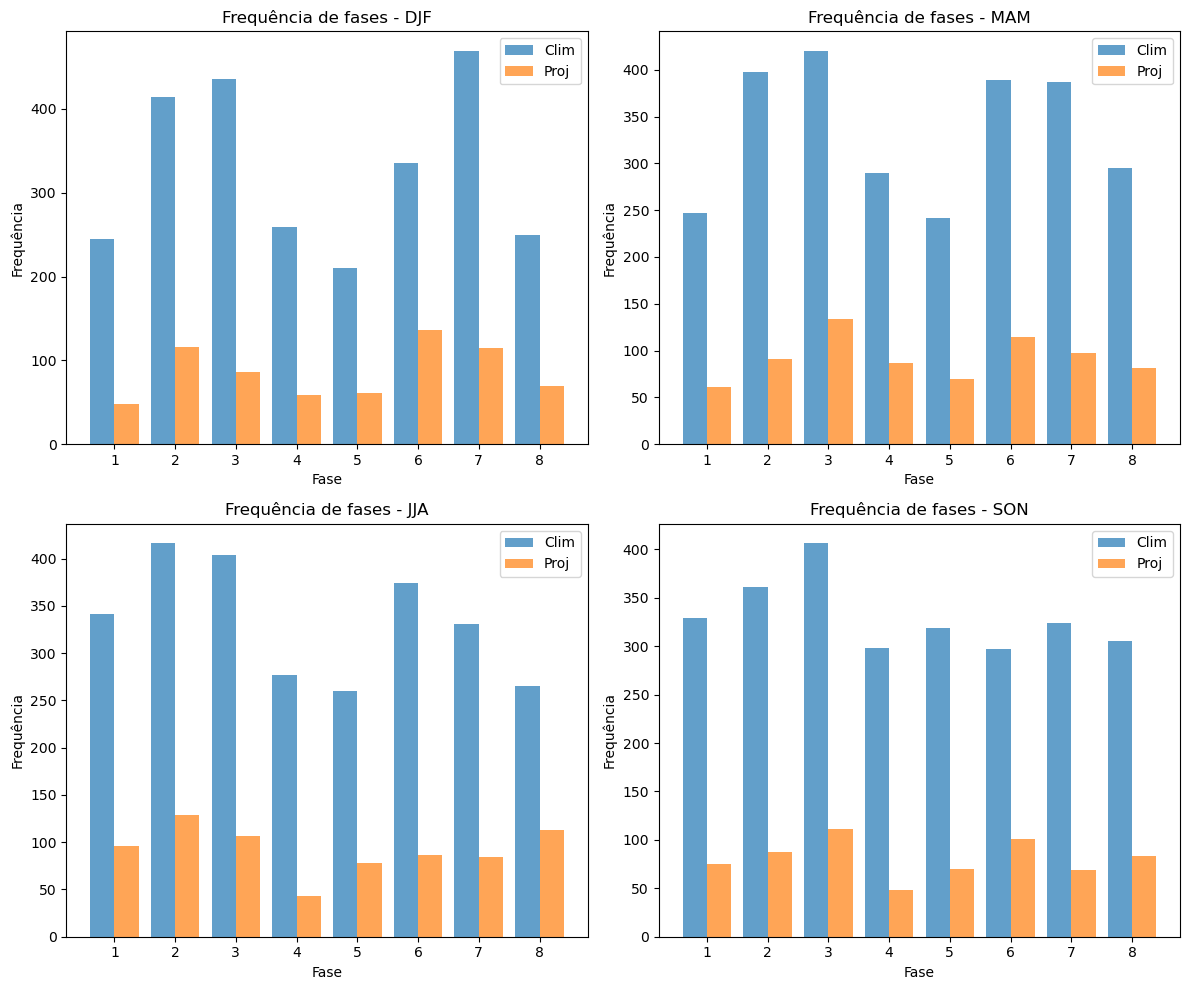

In [9]:

# ============================
# 5. Histogramas sazonais das fases
# ============================
phase_clim = clim.groupby(["Season","Phase"]).size().unstack(fill_value=0)
phase_proj = proj.groupby(["Season","Phase"]).size().unstack(fill_value=0)

seasons = ["DJF","MAM","JJA","SON"]
fig, axes = plt.subplots(2,2, figsize=(12,10))

for i, season in enumerate(seasons):
    ax = axes[i//2, i%2]
    if season in phase_clim.index:
        ax.bar(phase_clim.columns-0.2, phase_clim.loc[season], width=0.4, label="Clim", alpha=0.7)
    if season in phase_proj.index:
        ax.bar(phase_proj.columns+0.2, phase_proj.loc[season], width=0.4, label="Proj", alpha=0.7)
    ax.set_title(f"Frequência de fases - {season}")
    ax.set_xlabel("Fase")
    ax.set_ylabel("Frequência")
    ax.legend()

plt.tight_layout()
plt.show()

## Figura 3 — Séries temporais comparativas

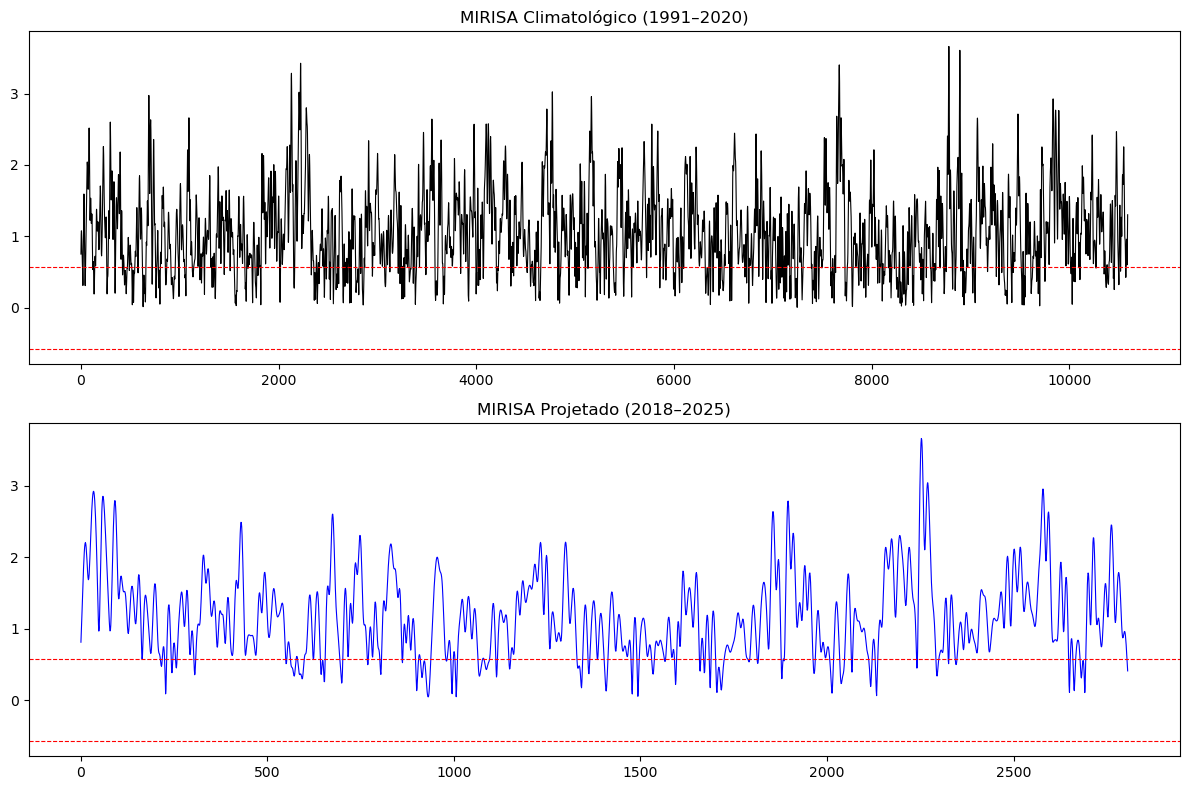

In [7]:
fig, axes = plt.subplots(2,1,figsize=(12,8), sharex=False)

axes[0].plot(mirisa_clim.index, mirisa_clim, 'k-', lw=0.8)
axes[0].axhline(mirisa_clim.std(), color='r', ls='--', lw=0.8)
axes[0].axhline(-mirisa_clim.std(), color='r', ls='--', lw=0.8)
axes[0].set_title("MIRISA Climatológico (1991–2020)")

axes[1].plot(mirisa_proj.index, mirisa_proj, 'b-', lw=0.8)
axes[1].axhline(mirisa_proj.std(), color='r', ls='--', lw=0.8)
axes[1].axhline(-mirisa_proj.std(), color='r', ls='--', lw=0.8)
axes[1].set_title("MIRISA Projetado (2018–2025)")

# axes[2].plot(rmm_amp.index, rmm_amp, 'g-', lw=0.8)
# axes[2].axhline(rmm_amp.std(), color='r', ls='--', lw=0.8)
# axes[2].axhline(-rmm_amp.std(), color='r', ls='--', lw=0.8)
# axes[2].set_title("RMM Amplitude (BoM)")

plt.tight_layout()
plt.show()

## Figura 4 — Histogramas de amplitude

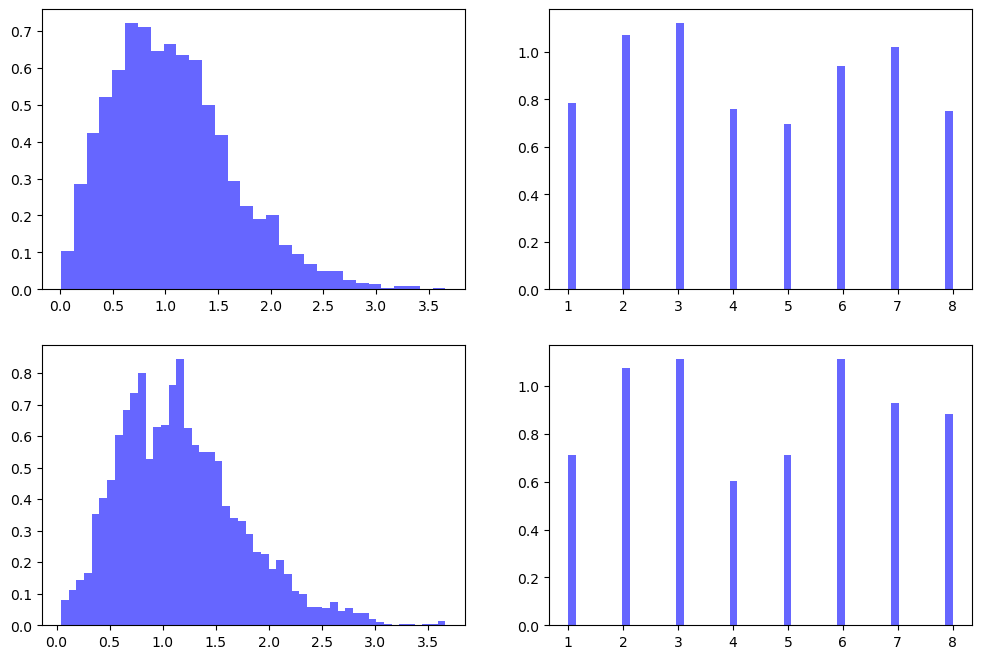

In [2]:
fig, axes = plt.subplots(2,2,figsize=(12,8), sharex=False)

axes[0,0].hist(miri_climA.abs(), bins=30, density=True, alpha=0.6, color='blue', label="1991–2020")
#axes[0].axvline(1.5, color='k', ls='--', lw=0.8, label="Limiar 1.5")
#axes[0].xlabel("Amplitude MIRI.SA")
#axes[0].ylabel("Densidade")
#axes[0].legend()
#axes[0].title("Distribuição de amplitude do MIRI.SA")

axes[0,1].hist(miri_climF.abs(), bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")
# axes[1].axvline(1.5, color='k', ls='--', lw=0.8, label="Limiar 1.5")
# axes[1].xlabel("Amplitude MIRI.SA")
# axes[1].ylabel("Densidade")
# axes[1].legend()
# axes[1].title("Distribuição de amplitude do MIRI.SA")

axes[1,0].hist(miri_projA.abs(), bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")
axes[1,1].hist(miri_projF.abs(), bins=50, density=True, alpha=0.6, color='blue', label="1991–2020")

plt.show()

Teste Figura 

C:\Users\Nete\AppData\Local\Temp\ipykernel_11208\2578338709.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


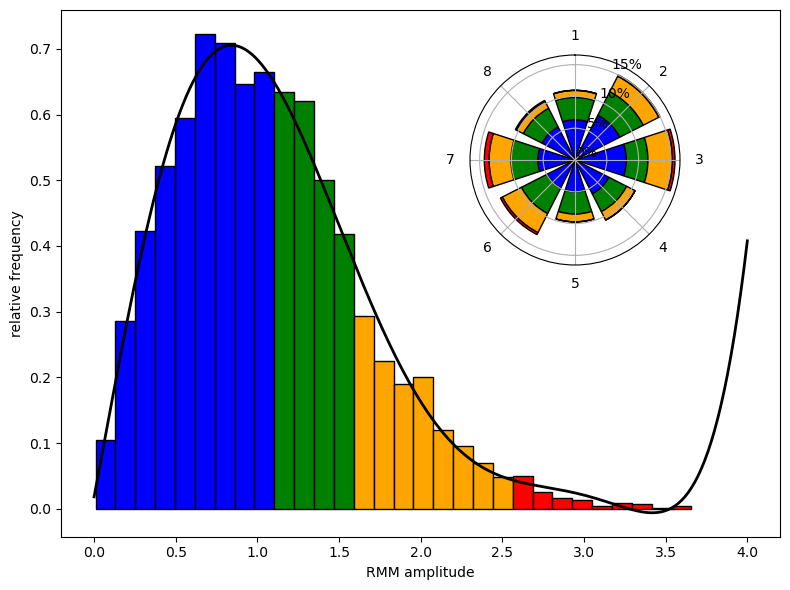

In [6]:
# -----------------------
# Exemplo de dados sintéticos
# -----------------------
np.random.seed(42)

# Amplitude do MJO (dados fictícios)
rmm_amplitude = miri_climA #np.random.gamma(2., 0.7, 5000)  # distribuição parecida com a da figura

# Fases do MJO (1 a 8)
phases = miri_climF #np.random.randint(1, 9, 5000)

# -----------------------
# Figura principal
# -----------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Histograma normalizado (frequência relativa)
counts, bins, bars = ax.hist(rmm_amplitude, bins=30, density=True, color="lightgray", edgecolor="k")

# Ajuste polinomial para suavizar a curva
x = np.linspace(0, 4, 200)
coeffs = np.polyfit((bins[:-1] + bins[1:]) / 2, counts, deg=6)
y_fit = np.polyval(coeffs, x)
ax.plot(x, y_fit, "k-", lw=2)

# Colorir barras por categorias de amplitude
colors = []
for b in bins[:-1]:
    if b < 1:
        colors.append("blue")
    elif b < 1.5:
        colors.append("green")
    elif b < 2.5:
        colors.append("orange")
    else:
        colors.append("red")

for bar, c in zip(bars, colors):
    bar.set_facecolor(c)

ax.set_xlabel("RMM amplitude")
ax.set_ylabel("relative frequency")

# -----------------------
# Subfigura polar (rosa dos ventos)
# -----------------------
ax_inset = plt.axes([0.55, 0.55, 0.35, 0.35], polar=True)

# Contagem por fase e categoria de amplitude
categories = [(0,1,"blue"), (1,1.5,"green"), (1.5,2.5,"orange"), (2.5,10,"red")]
phase_counts = np.zeros((8, len(categories)))

for i, (low, high, col) in enumerate(categories):
    mask = (rmm_amplitude >= low) & (rmm_amplitude < high)
    for p in range(1, 9):
        phase_counts[p-1, i] = np.sum(mask & (phases == p))

# Normalizar em %
phase_counts = phase_counts / phase_counts.sum() * 100

# Ângulos (8 fases → 8 setores de 45°)
theta = np.linspace(0, 2*np.pi, 9)[:-1]

# Largura de cada barra
width = 2*np.pi / 8 * 0.8

# Plotar barras empilhadas
bottom = np.zeros(8)
for i, (low, high, col) in enumerate(categories):
    bars = ax_inset.bar(theta, phase_counts[:, i], width=width, bottom=bottom, color=col, edgecolor="k")
    bottom += phase_counts[:, i]

# Ajustes do polar
ax_inset.set_theta_zero_location("N")
ax_inset.set_theta_direction(-1)
ax_inset.set_xticks(theta)
ax_inset.set_xticklabels([str(i) for i in range(1, 9)])
ax_inset.set_yticks(np.arange(0, 20, 5))
ax_inset.set_yticklabels([f"{i}%" for i in range(0, 20, 5)])

# -----------------------
# Legenda
# -----------------------
# legend_elements = [
#     Patch(facecolor="blue", edgecolor="k", label="0–1"),
#     Patch(facecolor="green", edgecolor="k", label="1–1.5"),
#     Patch(facecolor="orange", edgecolor="k", label="1.5–2.5"),
#     Patch(facecolor="red", edgecolor="k", label="≥2.5"),
# ]
# ax.legend(handles=legend_elements, title="Amplitude", loc="upper right")

plt.tight_layout()
plt.show()

## Tabela 1 — Frequência de categorias

In [10]:
def classifica_evento(val):
    if val < 1: return "Inativo"
    elif val < 1.5: return "Ativo"
    elif val < 2.5: return "Muito ativo"
    else: return "Extremo"

cats_clim = mirisa_clim.abs().apply(classifica_evento).value_counts(normalize=True)*100
cats_proj = mirisa_proj.abs().apply(classifica_evento).value_counts(normalize=True)*100

freq_table = pd.DataFrame({"Climatologia (1991–2020)": cats_clim,
                           "Projeção (2018–2025)": cats_proj}).fillna(0)
freq_table.round(1)

,Climatologia (1991–2020),Projeção (2018–2025)
Amplitude,,
Inativo,50.0,42.0
Ativo,29.7,32.5
Muito ativo,18.4,22.8
Extremo,1.9,2.7


## Figura 5 — Persistência e duração

In [1]:
def conta_runs(series, limiar=1.5):
    runs, count = [], 0
    for v in (series.abs() >= limiar):
        if v:
            count += 1
        else:
            if count > 0:
                runs.append(count)
                count = 0
    if count > 0:
        runs.append(count)
    return runs

runs_clim = conta_runs(mirisa_clim, limiar=1)
runs_proj = conta_runs(mirisa_proj, limiar=1)

plt.hist(runs_clim, bins=range(1,21), alpha=0.6, label="1991–2020")
plt.hist(runs_proj, bins=range(1,21), alpha=0.6, label="2018–2025")
plt.xlabel("Duração do evento (dias)")
plt.ylabel("Frequência")
plt.legend()
plt.title("Distribuição da persistência dos eventos MIRI.SA")
plt.show()

NameError: name 'mirisa_clim' is not defined

## Tabela 2 — Estatísticas de eventos

In [12]:
runs_stats = pd.DataFrame({
    "Climatologia": [np.mean(runs_clim), np.median(runs_clim), np.max(runs_clim), np.std(runs_clim)],
    "Projeção": [np.mean(runs_proj), np.median(runs_proj), np.max(runs_proj), np.std(runs_proj)]
}, index=["Média","Mediana","Máximo","Desvio padrão"])

runs_stats.round(2)

,Climatologia,Projeção
Média,20.15,23.96
Mediana,13.00,13.50
Máximo,88.00,160.00
Desvio padrão,17.17,25.73


## Figura 6 e 7 — Composites por fase e diferenças

In [13]:
def calcula_fase(series):
    # Placeholder: calcule fase a partir de PCs (atan2), aqui apenas exemplo aleatório
    return pd.Series(np.random.randint(1,9,len(series)), index=series.index)

fase_clim = calcula_fase(mirisa_clim)
fase_proj = calcula_fase(mirisa_proj)

# Exemplo: composite de precip para fase 1
comp_clim = precip.sel(time=fase_clim[fase_clim==1].index).mean("time")
comp_proj = precip.sel(time=fase_proj[fase_proj==1].index).mean("time")

diff = comp_proj - comp_clim
diff.plot(cmap="RdBu_r")
plt.title("Diferença de precipitação - Fase 1 (Proj - Clim)")
plt.show()

NameError: name 'precip' is not defined

## Figura 8 — Probabilidade de extremos

In [14]:
def prob_extremos(serie_precip, fase_index, thr=95):
    probs = {}
    p95 = np.percentile(serie_precip, thr)
    for f in range(1,9):
        vals = serie_precip.sel(time=fase_index[fase_index==f].index)
        probs[f] = np.mean(vals > p95)
    return probs

probs_clim = prob_extremos(precip, fase_clim, thr=95)
probs_proj = prob_extremos(precip, fase_proj, thr=95)

df_probs = pd.DataFrame({"Clim":probs_clim, "Proj":probs_proj})
x = np.arange(1,9)  # fases
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width/2, list(probs_clim.values()), width, label="Clim (1991–2020)", color="blue", alpha=0.7)
ax.bar(x + width/2, list(probs_proj.values()), width, label="Proj (2018–2025)", color="red", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"Fase {i}" for i in x])
ax.set_ylabel("Probabilidade de extremos (>95º)")
ax.set_title("Probabilidade condicional de extremos por fase")
ax.legend()
plt.show()

NameError: name 'precip' is not defined

## Tabela 3 — Testes estatísticos

In [15]:
tstat, pval = ttest_ind(mirisa_clim.abs(), mirisa_proj.abs(), equal_var=False)
print("Teste t (amplitude climatologia vs projeção): p =", pval)

Teste t (amplitude climatologia vs projeção): p = 8.638937926024679e-18


## Figura 9 — Hovmöller

In [ ]:
olr_band_clim = olr.sel(time=slice("1991-03-01","2020-02-28")).mean("lat")
olr_band_proj = olr.sel(time=slice("2018-01-01","2025-09-07")).mean("lat")

fig, axes = plt.subplots(2,1,figsize=(12,6), sharex=True)
olr_band_clim.plot.imshow(ax=axes[0], cmap="RdBu_r", vmin=-20, vmax=20)
axes[0].set_title("Hovmöller OLR (1991–2020)")
olr_band_proj.plot.imshow(ax=axes[1], cmap="RdBu_r", vmin=-20, vmax=20)
axes[1].set_title("Hovmöller OLR (2018–2025)")
plt.tight_layout()
plt.show()